In [69]:
import treecorr
import numpy as np
import matplotlib.pyplot as plt
import os
from astropy.io import fits
#import fitsio
from astropy.table import Table
#import csv 
import pandas as pd
import polars as pl

try:
    plt.style.use('/home/dy9683/cosmic-shear/cosmic-shear-with-spec-z/paperfigs.mplstyle')
except Exception as e:
    print(f'Error: {e}')
    # print(f"Could not find style file paperfigs.mplstyle")

# Load Catalog

HSC Y3 Matched from Jared

In [48]:
hscy3 = '/scratch/gpfs/js1998/matched_catalogs/hscy3_matched.csv'
# hscy3 = '/scratch/gpfs/dy9683/hscy3_matched.h5'

In [55]:
file_path = hscy3
hsc_catalog = pl.scan_csv(file_path).filter(pl.col('lensing_match') == 1).collect()

In [39]:
hsc_catalog

In [58]:
ra = hsc_catalog['TARGET_RA']
dec = hsc_catalog['TARGET_DEC']
g1 = hsc_catalog['e1'] 
g2 = hsc_catalog['e2']
z = hsc_catalog['Z_BEST']

# Plots

In [60]:
print(f'Number of sources: {len(hsc_catalog):,}')

Number of sources: 1,358,425


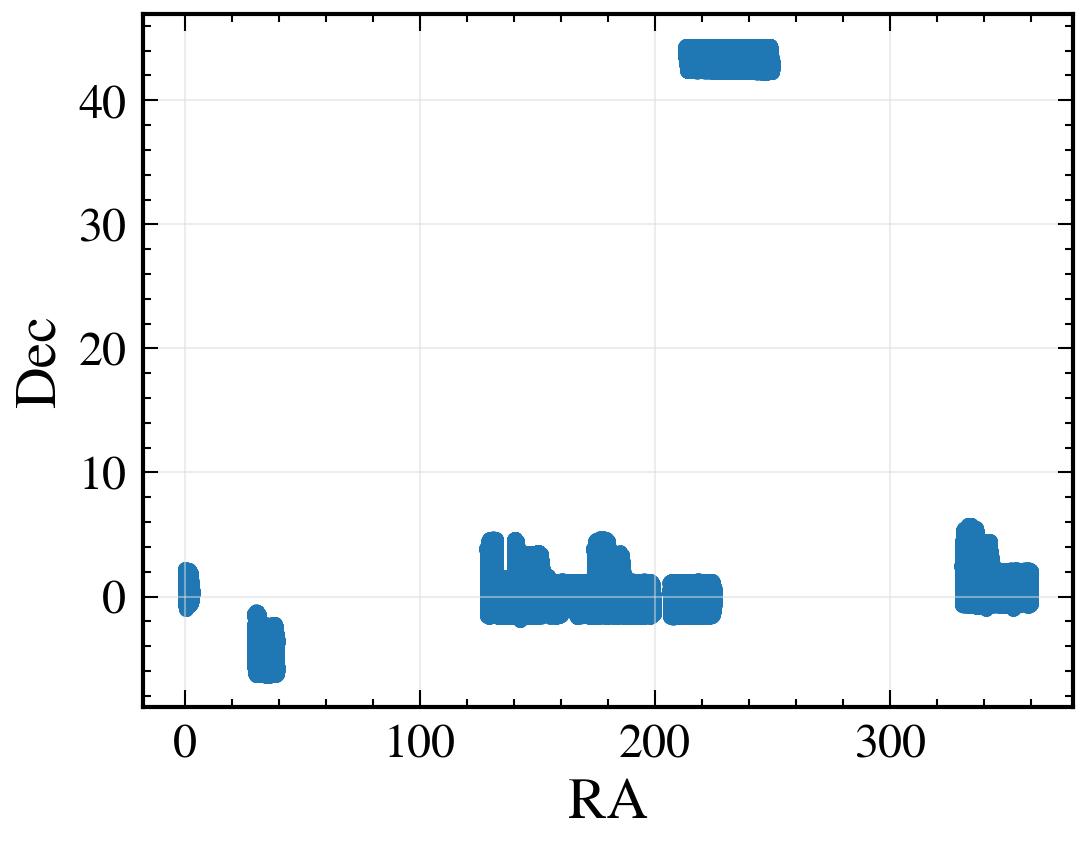

In [70]:
# ra v dec
fig, ax = plt.subplots(figsize = (8,6))
ax.scatter(ra, dec)
ax.set_xlabel("RA")
ax.set_ylabel("Dec")
#ax.set_xlim(0, 360)
#ax.set_ylim(-30, 30)
plt.show()

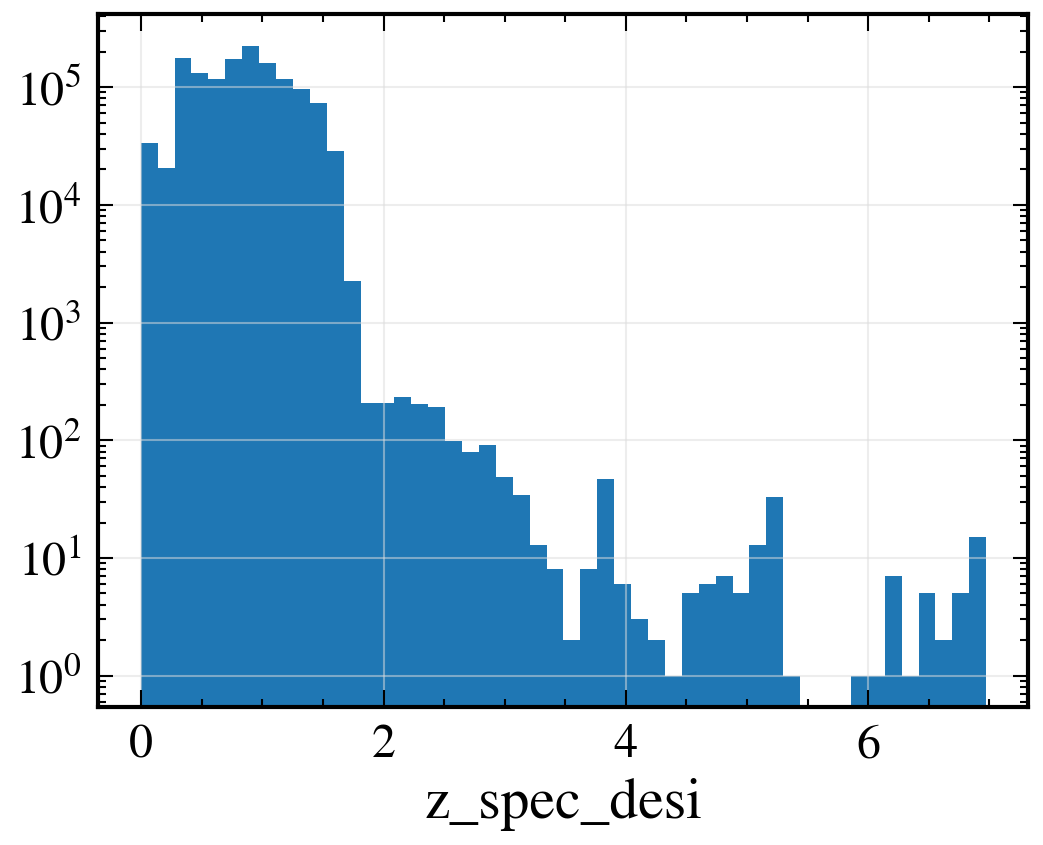

In [71]:
# histogram of redshifts
fig, ax = plt.subplots(figsize = (8,6))
ax.hist(z, bins = 50 , density = False)
ax.set_xlabel("z_spec_desi")
ax.set_yscale('log')
plt.show()

# TreeCorr Calculations

https://rmjarvis.github.io/TreeCorr/_build/html/gg.html

In [63]:
cat = treecorr.Catalog(ra=ra, dec=dec, g1=g1, g2=g2, ra_units='degrees', dec_units='degrees')
gg = treecorr.GGCorrelation(min_sep=1.0, max_sep=100.0, nbins=20, sep_units='arcmin')
gg.process(cat)

r = np.exp(gg.meanlogr)

# correlation functions
#xi_+
xip = gg.xip
# # xi_-
xim = gg.xim

#calculate variance
sig_xip = np.sqrt(gg.varxip)
sig_xim = np.sqrt(gg.varxim)

# $\xi_{+/-}$ Plot

In [64]:
xip

array([ 7.96474311e-04, -2.92355020e-04, -9.18420845e-05,  6.04405603e-04,
        3.36623779e-04,  3.79145697e-04,  3.20022929e-04,  1.01394239e-04,
        3.98168415e-05, -1.08792029e-05, -4.84039191e-05,  1.37992998e-06,
        4.07009731e-05,  6.51792123e-05,  2.55598238e-05,  1.77295350e-05,
        1.05124731e-05,  3.92684100e-08,  9.57152928e-06, -6.85843262e-06])

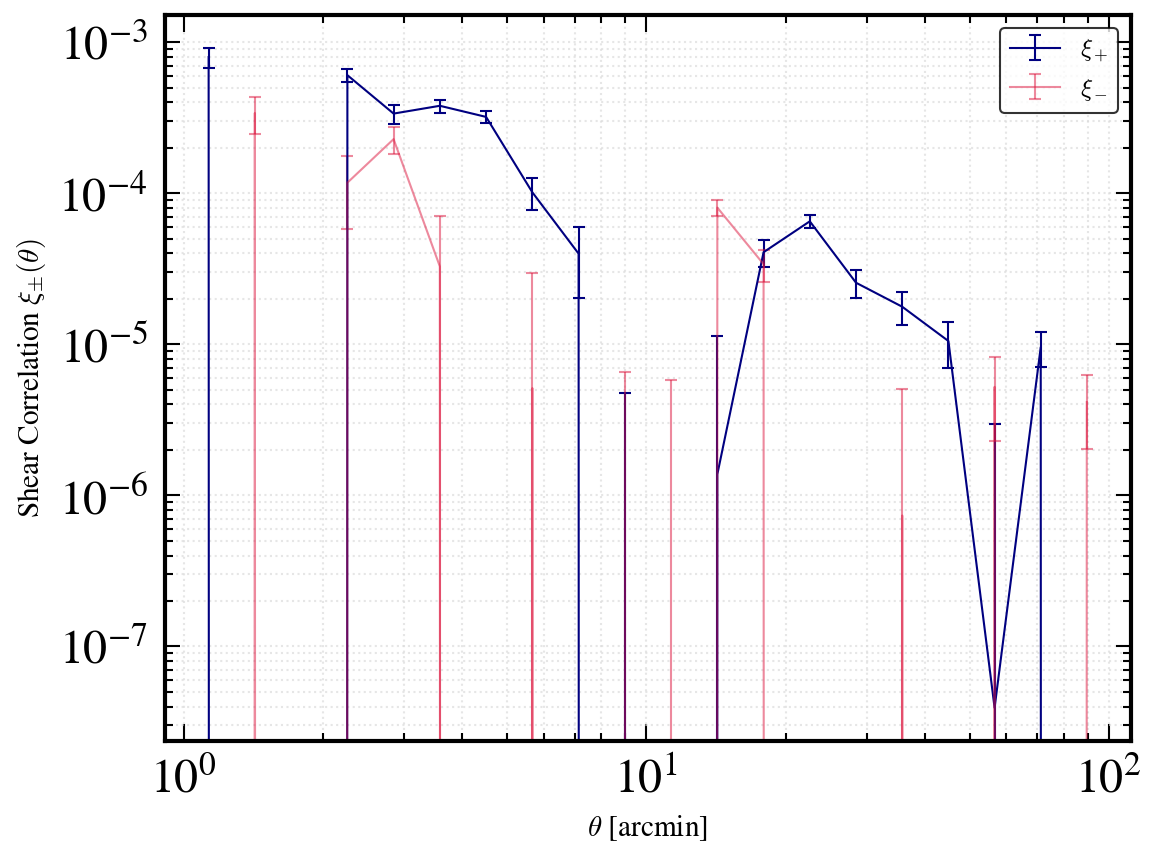

In [72]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.errorbar(r, xip, yerr=sig_xip, label=r'$\xi_+$', color='navy', capsize=3)
ax.errorbar(r, xim, yerr=sig_xim, label=r'$\xi_-$', color='crimson', capsize=3, alpha = 0.5)

ax.set_xscale('log')
ax.set_yscale('log') 
ax.set_xlabel(r'$\theta$ [arcmin]', fontsize=14)
ax.set_ylabel(r'Shear Correlation $\xi_{\pm}(\theta)$', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, which='both', linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

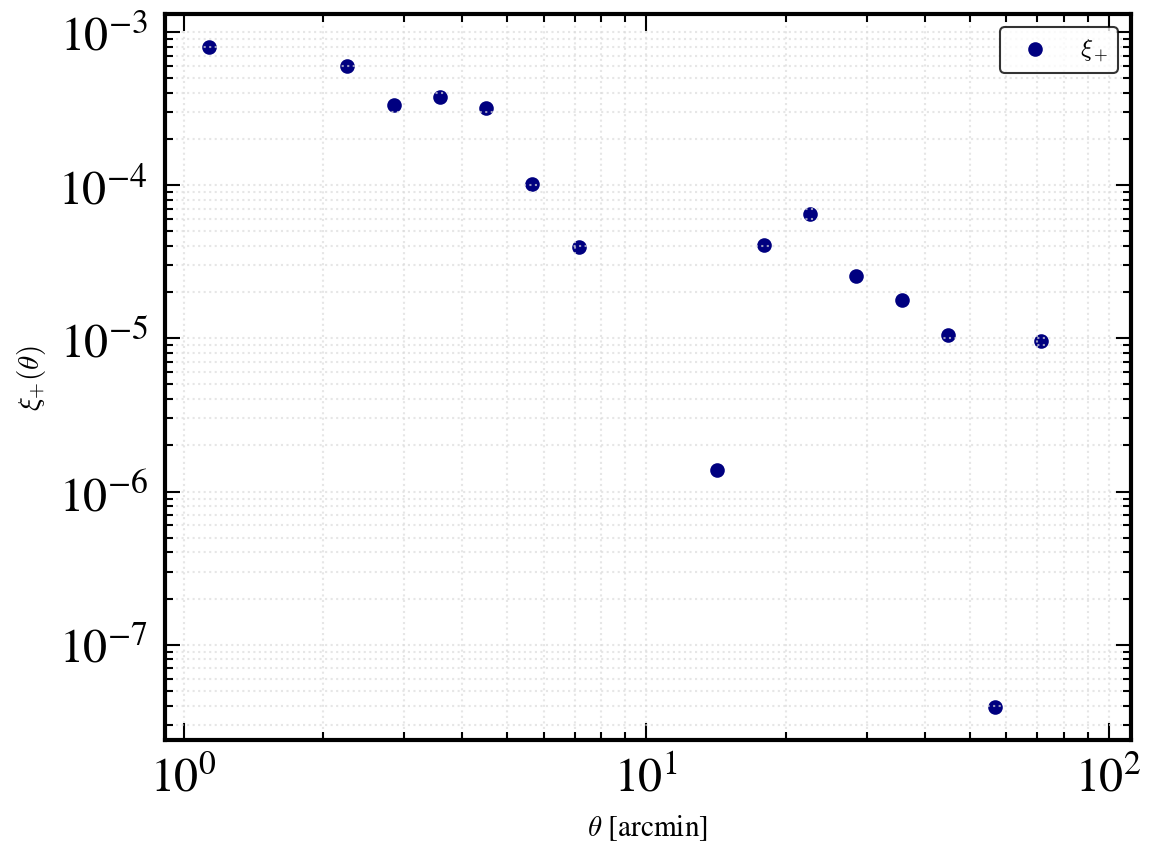

In [73]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(r, xip, label=r'$\xi_+$', color='navy')

ax.set_xscale('log')
ax.set_yscale('log') 
ax.set_xlabel(r'$\theta$ [arcmin]', fontsize=14)
ax.set_ylabel(r'$\xi_{+}(\theta)$', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, which='both', linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()